<a href="https://colab.research.google.com/github/Axlbenja/axel.paredes/blob/main/Optimizing_Park_Accessibility_and_Equity_in_Miami_Dade_County_%E2%80%94_Axel_Paredes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Optimizing Park Accessibility in Miami-Dade County

In [65]:
!pip install geopy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import plotly.express as px
import folium
import plotly.express as px

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from folium import Circle
from geopy.geocoders import Nominatim
from folium.plugins import MarkerCluster

#Problem Statement & Business Value

Access to parks isn’t just a matter of recreation—it’s tied to public health, quality of life, and community well-being. In Miami-Dade County, where income and resources vary widely between municipalities, not all neighborhoods get equal access to green spaces.

This project examines how park access aligns with population size and economic need, combining datasets such as park acreage, SNAP (food assistance) participation, and demographics. The aim? To identify gaps in park access and pinpoint areas that could benefit from targeted investment the most. By merging datasets and mapping patterns across the county, this analysis highlights where green spaces are lacking, especially in communities that need them most. This could lead to more intelligent resource allocation for locals and enhanced urban planning.

On the academic side, it showcases data science in action, merging datasets, conducting exploratory analysis, and utilizing clustering to uncover hidden inequities. What’s cool about this isn’t just the numbers—it’s the equity angle. It’s about spotlighting overlooked neighborhoods with data and showing how analysis can spark fairer, more intelligent decisions. Better park access could mean healthier people, tighter communities, and a more connected Miami-Dade County.

In [2]:
#Datasets from GitHub
age_sex_url = "https://raw.githubusercontent.com/Axlbenja/axel.paredes/refs/heads/main/Age%26Sex_cleaned.csv"
snap_url = "https://raw.githubusercontent.com/Axlbenja/axel.paredes/refs/heads/main/FoodStamps(SNAP)_cleaned.csv"
park_url = "https://raw.githubusercontent.com/Axlbenja/axel.paredes/refs/heads/main/MunicipalParkDataset_cleaned.csv"
pop_url = "https://raw.githubusercontent.com/Axlbenja/axel.paredes/refs/heads/main/PopulationEstimates_cleaned.csv"

In [3]:
age_sex_cleaned = pd.read_csv(age_sex_url)
snap_cleaned = pd.read_csv(snap_url)
park_agg_cleaned = pd.read_csv(park_url)
pop_cleaned = pd.read_csv(pop_url)

#Merging the data to consolidate the info

In [4]:
for df in [age_sex_cleaned, snap_cleaned, park_agg_cleaned, pop_cleaned]:
    df.columns = df.columns.str.strip()
    df['Municipality'] = df['Municipality'].str.lower().str.strip()

In [5]:
merged_df = pop_cleaned.copy()

In [6]:
merged_df = merged_df.merge(park_agg_cleaned, on='Municipality', how='left')
merged_df = merged_df.merge(age_sex_cleaned, on='Municipality', how='left')
merged_df = merged_df.merge(snap_cleaned, on='Municipality', how='left')

In [7]:
merged_df['Number_of_Parks'] = merged_df['Number_of_Parks'].fillna(0)
merged_df['Total_Acreage'] = merged_df['Total_Acreage'].fillna(0)

In [8]:
merged_df.rename(columns={
    'Population_2023': 'Population_2023',
    'SNAP_Pct_Total': 'SNAP_Percent',
    'SNAP_Pct_Under_18': 'SNAP_Percent_Under_18',
    'SNAP_Total_Households': 'SNAP_Total_Households',
    'Development_Status_Distribution': 'Development_Status_Distribution'
}, inplace=True)

In [9]:
print(merged_df.columns)

Index(['Municipality', 'Population_2023', 'Number_of_Parks', 'Total_Acreage',
       'Park_Class_Distribution', 'Development_Status_Distribution',
       'Percent_Under_18', 'Percent_65_plus', 'SNAP_Percent',
       'SNAP_Percent_Under_18', 'SNAP_Total_Households'],
      dtype='object')


In [10]:
merged_df = merged_df[merged_df['Population_2023'].notna()]

In [11]:
merged_df['Parks_Per_Capita'] = merged_df['Number_of_Parks'] / merged_df['Population_2023']
merged_df['Acreage_Per_1000'] = merged_df['Total_Acreage'] / (merged_df['Population_2023'] / 1000)

In [12]:
final_columns = [
    'Municipality',
    'Population_2023',
    'Number_of_Parks',
    'Total_Acreage',
    'Park_Class_Distribution',
    'Development_Status_Distribution',
    'Percent_Under_18',
    'Percent_65_plus',
    'SNAP_Percent',
    'SNAP_Percent_Under_18',
    'SNAP_Total_Households',
    'Parks_Per_Capita',
    'Acreage_Per_1000'
]
merged_df = merged_df[final_columns]

In [13]:
filename = "parks_equity_miami_dade.csv"
merged_df.to_csv(filename, index=False)

In [14]:
print("\nPreview of Final Dataset:")
print(merged_df.head())
print("\nDataset Shape:", merged_df.shape)
print("\nMissing Values:")
print(merged_df.isnull().sum())


Preview of Final Dataset:
         Municipality  Population_2023  Number_of_Parks  Total_Acreage  \
0            aventura            39192              7.0           37.2   
1         bal harbour             2973              0.0            0.0   
2  bay harbor islands             5634              0.0            0.0   
3       biscayne park             3018              0.0            0.0   
4        coral gables            48678             47.0          250.5   

                             Park_Class_Distribution  \
0          Community/Neighborhood: 5; Single Purp...   
1                                                NaN   
2                                                NaN   
3                                                NaN   
4          Community/Neighborhood: 29; Single Pur...   

  Development_Status_Distribution  Percent_Under_18  Percent_65_plus  \
0              Fully Developed: 7               NaN              NaN   
1                             NaN              

In [15]:
merged_df.iloc[:5, :5]

,Municipality,Population_2023,Number_of_Parks,Total_Acreage,Park_Class_Distribution
0,aventura,39192,7.0,37.2,Community/Neighborhood: 5; Single Purp...
1,bal harbour,2973,0.0,0.0,NaN
2,bay harbor islands,5634,0.0,0.0,NaN
3,biscayne park,3018,0.0,0.0,NaN
4,coral gables,48678,47.0,250.5,Community/Neighborhood: 29; Single Pur...


In [16]:
merged_df.columns[:5]

Index(['Municipality', 'Population_2023', 'Number_of_Parks', 'Total_Acreage',
       'Park_Class_Distribution'],
      dtype='object')

#Merged Data

In [17]:
merged_df = pd.read_csv('parks_equity_miami_dade.csv')
print("Merged Dataset Preview:")
print(merged_df.head())
print("\nDataset Info:")
print(merged_df.info())
print("\nMissing Values:")
print(merged_df.isnull().sum())

Merged Dataset Preview:
         Municipality  Population_2023  Number_of_Parks  Total_Acreage  \
0            aventura            39192              7.0           37.2   
1         bal harbour             2973              0.0            0.0   
2  bay harbor islands             5634              0.0            0.0   
3       biscayne park             3018              0.0            0.0   
4        coral gables            48678             47.0          250.5   

                             Park_Class_Distribution  \
0          Community/Neighborhood: 5; Single Purp...   
1                                                NaN   
2                                                NaN   
3                                                NaN   
4          Community/Neighborhood: 29; Single Pur...   

  Development_Status_Distribution  Percent_Under_18  Percent_65_plus  \
0              Fully Developed: 7               NaN              NaN   
1                             NaN               Na

##Analysis:

In [18]:
#Identify low-access municipalities
low_access_parks = merged_df[['Municipality', 'Population_2023', 'Number_of_Parks', 'Parks_Per_Capita']].sort_values(by='Parks_Per_Capita').head(10)
print("\nMunicipalities with Lowest Parks Per Capita:")
print(low_access_parks)


Municipalities with Lowest Parks Per Capita:
          Municipality  Population_2023  Number_of_Parks  Parks_Per_Capita
1          bal harbour             2973              0.0          0.000000
2   bay harbor islands             5634              0.0          0.000000
3        biscayne park             3018              0.0          0.000000
5           cutler bay            43681              0.0          0.000000
7            el portal             1905              0.0          0.000000
9         golden beach              563              0.0          0.000000
13        indian creek               81              0.0          0.000000
22           north bay             7375              0.0          0.000000
32    virginia gardens             2310              0.0          0.000000
11     hialeah gardens            22540              2.0          0.000089


In [19]:
low_access_acreage = merged_df[['Municipality', 'Population_2023', 'Total_Acreage', 'Acreage_Per_1000']].sort_values(by='Acreage_Per_1000').head(10)
print("\nMunicipalities with Lowest Acreage Per 1,000 Residents:")
print(low_access_acreage)


Municipalities with Lowest Acreage Per 1,000 Residents:
          Municipality  Population_2023  Total_Acreage  Acreage_Per_1000
1          bal harbour             2973            0.0          0.000000
2   bay harbor islands             5634            0.0          0.000000
3        biscayne park             3018            0.0          0.000000
5           cutler bay            43681            0.0          0.000000
7            el portal             1905            0.0          0.000000
9         golden beach              563            0.0          0.000000
13        indian creek               81            0.0          0.000000
22           north bay             7375            0.0          0.000000
32    virginia gardens             2310            0.0          0.000000
11     hialeah gardens            22540            2.5          0.110914


# Equity analysis

In [20]:
equity_df = merged_df[merged_df['SNAP_Percent'].notna()]
correlation_snap_parks = equity_df['SNAP_Percent'].corr(equity_df['Parks_Per_Capita'])
print(f"\nCorrelation between SNAP_Percent and Parks_Per_Capita: {correlation_snap_parks:.3f}")
correlation_age_parks = equity_df['Percent_Under_18'].corr(equity_df['Parks_Per_Capita'])
print(f"Correlation between Percent_Under_18 and Parks_Per_Capita: {correlation_age_parks:.3f}")


Correlation between SNAP_Percent and Parks_Per_Capita: -0.384
Correlation between Percent_Under_18 and Parks_Per_Capita: -0.225


### Parse park class distribution

In [21]:
def safe_literal_eval(x):
    try:
        return ast.literal_eval(x) if pd.notna(x) else {}
    except (SyntaxError, ValueError):
        return {}

In [22]:
merged_df['Park_Class_Distribution'] = merged_df['Park_Class_Distribution'].apply(safe_literal_eval)
merged_df['Community_Neighborhood_Parks'] = merged_df['Park_Class_Distribution'].apply(
    lambda x: x.get('Community/Neighborhood', 0)
)

#Adding calculated columns for underserved areas

In [23]:
median_parks = merged_df['Parks_Per_Capita'].median()
median_snap = merged_df['SNAP_Percent'].median()
merged_df['Is_Underserved'] = (merged_df['Parks_Per_Capita'] < median_parks) & (merged_df['SNAP_Percent'] > median_snap)
merged_df['Missing_Data'] = merged_df['SNAP_Percent'].isna()
print("\nUnderserved Municipalities (Low Parks, High SNAP):")
print(merged_df[merged_df['Is_Underserved']][['Municipality', 'Parks_Per_Capita', 'SNAP_Percent']])
print("\nMunicipalities with Missing SNAP/Age Data:")
print(merged_df[merged_df['Missing_Data']][['Municipality']])


Underserved Municipalities (Low Parks, High SNAP):
     Municipality  Parks_Per_Capita  SNAP_Percent
10        hialeah          0.000132          41.7
18  miami gardens          0.000108          29.5

Municipalities with Missing SNAP/Age Data:
          Municipality
0             aventura
1          bal harbour
2   bay harbor islands
3        biscayne park
4         coral gables
5           cutler bay
7            el portal
8         florida city
9         golden beach
11     hialeah gardens
13        indian creek
14        key biscayne
15              medley
19         miami lakes
20        miami shores
21       miami springs
22           north bay
23         north miami
24   north miami beach
25           opa-locka
26        palmetto bay
27           pinecrest
28         south miami
29   sunny isles beach
30            surfside
31          sweetwater
32    virginia gardens
33          west miami


##Visualizations

1. Parks Per Capita


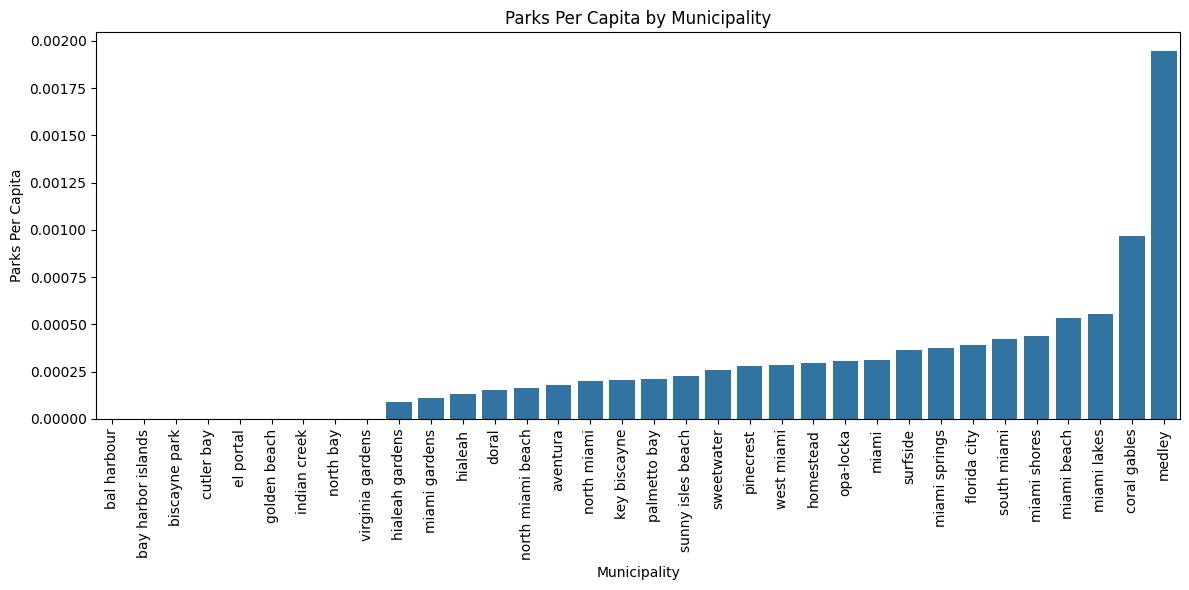

In [24]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Municipality', y='Parks_Per_Capita', data=merged_df.sort_values('Parks_Per_Capita'))
plt.xticks(rotation=90)
plt.title('Parks Per Capita by Municipality')
plt.xlabel('Municipality')
plt.ylabel('Parks Per Capita')
plt.tight_layout()
plt.show()

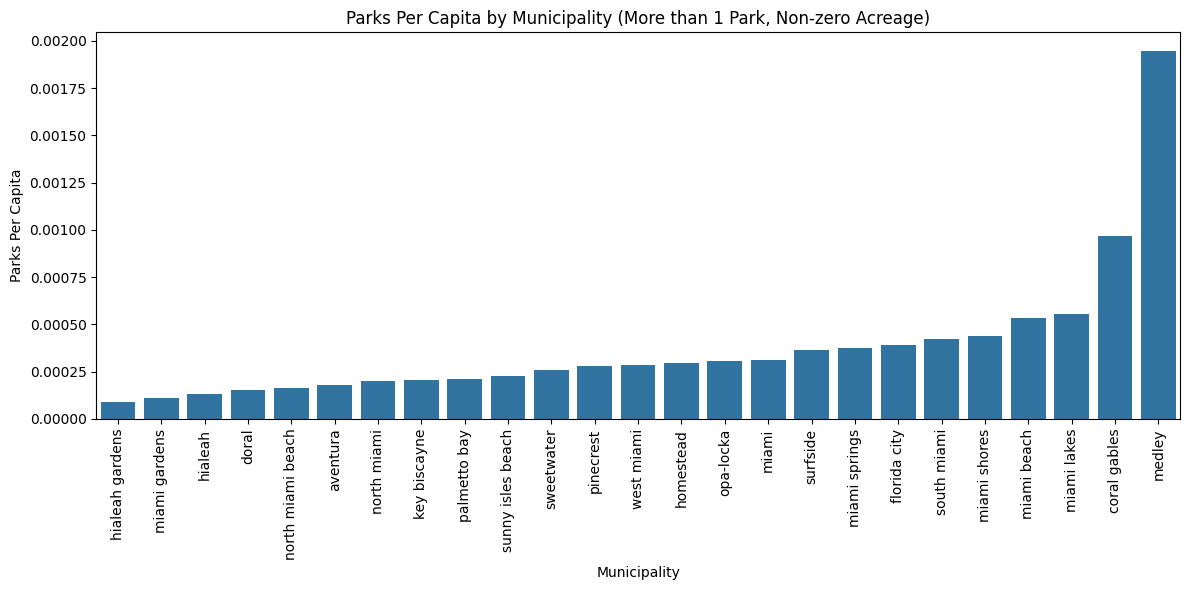

In [25]:
#Where there is info on parks and info on acreage
filtered_df = merged_df[(merged_df['Number_of_Parks'] > 1) & (merged_df['Total_Acreage'] > 0)]


plt.figure(figsize=(12, 6))
sns.barplot(x='Municipality', y='Parks_Per_Capita', data=filtered_df.sort_values('Parks_Per_Capita'))
plt.xticks(rotation=90)
plt.title('Parks Per Capita by Municipality (More than 1 Park, Non-zero Acreage)')
plt.xlabel('Municipality')
plt.ylabel('Parks Per Capita')
plt.tight_layout()
plt.show()


2. SNAP Participation vs. Parks Per Capita with Threshold Lines

<ipython-input-26-6f902acbfecd>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  equity_df['Parks_Per_1000'] = equity_df['Parks_Per_Capita'] * 1000
<ipython-input-26-6f902acbfecd>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  equity_df['Color'] = equity_df.apply(


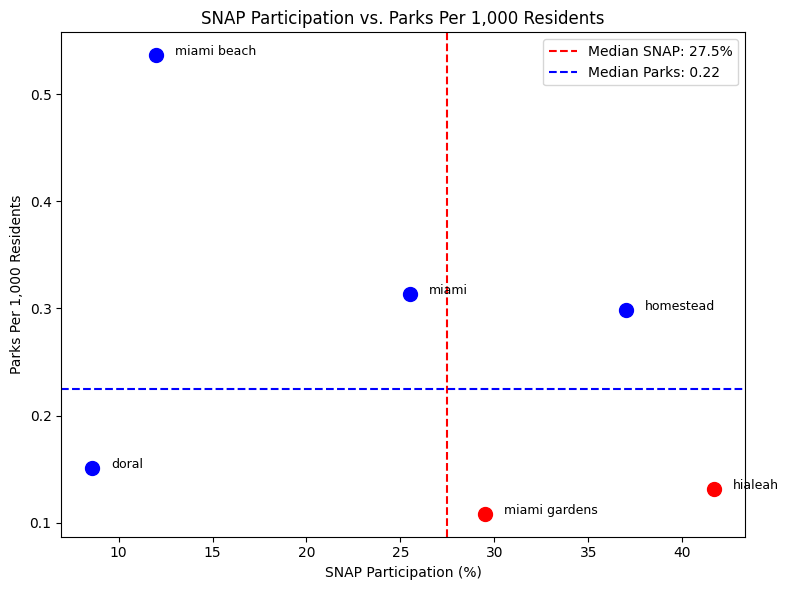

In [26]:
equity_df['Parks_Per_1000'] = equity_df['Parks_Per_Capita'] * 1000
median_parks_per_1000 = equity_df['Parks_Per_1000'].median()
median_snap = equity_df['SNAP_Percent'].median()
equity_df['Color'] = equity_df.apply(
    lambda row: 'red' if (row['SNAP_Percent'] > median_snap and row['Parks_Per_1000'] < median_parks_per_1000) else 'blue',
    axis=1
)
plt.figure(figsize=(8, 6))
for i, row in equity_df.iterrows():
    plt.scatter(row['SNAP_Percent'], row['Parks_Per_1000'], color=row['Color'], s=100)
    plt.text(row['SNAP_Percent'] + 1, row['Parks_Per_1000'], row['Municipality'], fontsize=9)
plt.axvline(median_snap, linestyle='--', color='red', label=f'Median SNAP: {median_snap:.1f}%')
plt.axhline(median_parks_per_1000, linestyle='--', color='blue', label=f'Median Parks: {median_parks_per_1000:.2f}')
plt.title('SNAP Participation vs. Parks Per 1,000 Residents')
plt.xlabel('SNAP Participation (%)')
plt.ylabel('Parks Per 1,000 Residents')
plt.legend()
plt.tight_layout()
plt.show()


3. Grouped Bar Chart for Community/Neighborhood Parks and Youth Population

In [27]:
age_data_df = merged_df[merged_df['Percent_Under_18'].notna()]

<ipython-input-28-068ae77c37c4>:9: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax1.set_ylim(0, max(age_data_df['Community_Neighborhood_Parks']) * 1.1)


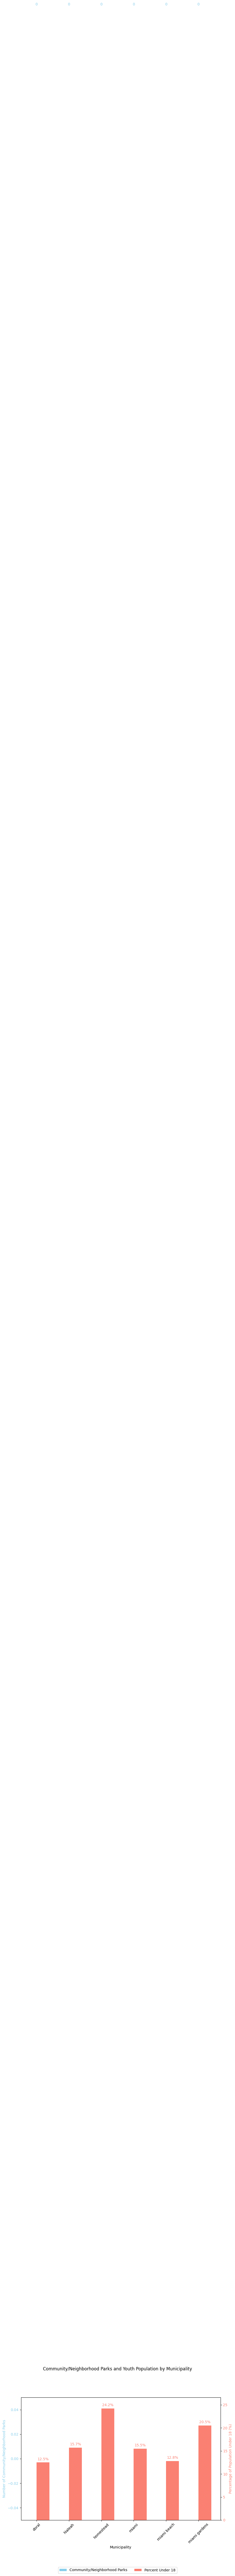

In [28]:
age_data_df = merged_df[merged_df['Percent_Under_18'].notna()]
fig, ax1 = plt.subplots(figsize=(10, 7))
bars1 = ax1.bar(age_data_df['Municipality'], age_data_df['Community_Neighborhood_Parks'], color='skyblue', label='Community/Neighborhood Parks', width=0.4, align='center')
ax1.set_xlabel('Municipality')
ax1.set_ylabel('Number of Community/Neighborhood Parks', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.set_xticks(range(len(age_data_df)))
ax1.set_xticklabels(age_data_df['Municipality'], rotation=45)
ax1.set_ylim(0, max(age_data_df['Community_Neighborhood_Parks']) * 1.1)
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 2, int(yval), ha='center', color='skyblue')
ax2 = ax1.twinx()
bars2 = ax2.bar(age_data_df['Municipality'], age_data_df['Percent_Under_18'], color='salmon', label='Percent Under 18', width=0.4, align='edge')
ax2.set_ylabel('Percentage of Population Under 18 (%)', color='salmon')
ax2.tick_params(axis='y', labelcolor='salmon')
ax2.set_ylim(0, max(age_data_df['Percent_Under_18']) * 1.1)
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.1f}%', ha='center', color='salmon')
fig.suptitle('Community/Neighborhood Parks and Youth Population by Municipality', y=1.05)
fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2)
plt.subplots_adjust(bottom=0.2)
plt.show()

#Multivariate EDA

In [32]:
correlation_columns = [
    'Parks_Per_Capita',
    'Acreage_Per_1000',
    'Population_2023',
    'SNAP_Percent'
]

In [33]:
corr_df = merged_df[correlation_columns].dropna()

In [34]:
corr_matrix = corr_df.corr()

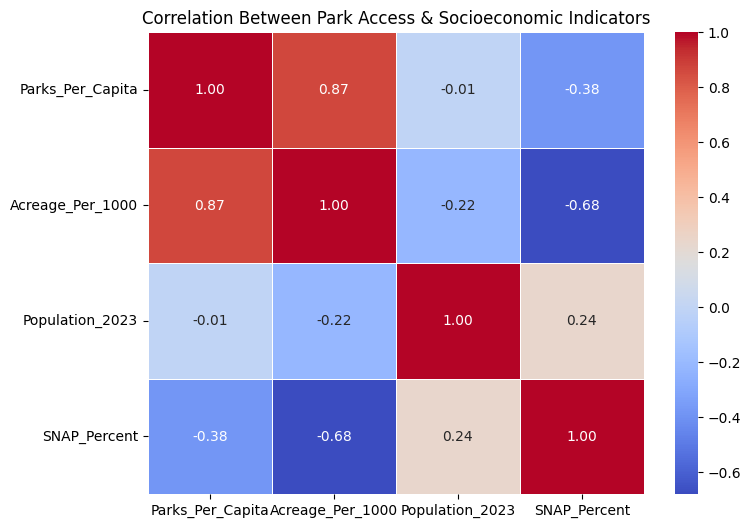

In [35]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f")
plt.title("Correlation Between Park Access & Socioeconomic Indicators")
plt.show()

The correlation heatmap indicates that municipalities with a higher number of parks per capita also tend to have more park acreage per 1,000 residents. However, areas with higher SNAP participation (a proxy for economic need) tend to have less park access, both in terms of the number of parks and the total acreage. This suggests a possible equity gap in public green space availability.

#3D scatter plot

In [36]:
scatter_df = merged_df[['Parks_Per_Capita', 'Acreage_Per_1000', 'Population_2023', 'SNAP_Percent', 'Municipality']].dropna()

In [39]:
fig = px.scatter_3d(
    scatter_df,
    x='Parks_Per_Capita',
    y='Acreage_Per_1000',
    z='SNAP_Percent',
    color='Population_2023',
    hover_name='Municipality',
    title='3D View: Park Access, Need & Population',
    labels={
        'Parks_Per_Capita': 'Parks per Capita',
        'Acreage_Per_1000': 'Acreage per 1,000 Residents',
        'SNAP_Percent': 'SNAP %',
        'Population_2023': 'Population (2023)'
    }
)

fig.show()

The 3D scatter plot helps us visualize that gap. You can see how municipalities with higher SNAP percentages often cluster in the lower range for both parks per capita and acreage, especially when population is taken into account. This confirms the idea that some of the most economically vulnerable areas may also be the most underserved in terms of parks.

#K-Means Clustering

In [41]:
clustering_df = merged_df[['Municipality', 'Parks_Per_Capita', 'Acreage_Per_1000', 'SNAP_Percent', 'Population_2023']].dropna()

In [42]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(clustering_df[['Parks_Per_Capita', 'Acreage_Per_1000', 'SNAP_Percent', 'Population_2023']])

In [43]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

In [44]:
clusters = kmeans.fit_predict(X_scaled)

In [45]:
clustering_df['Cluster'] = clusters

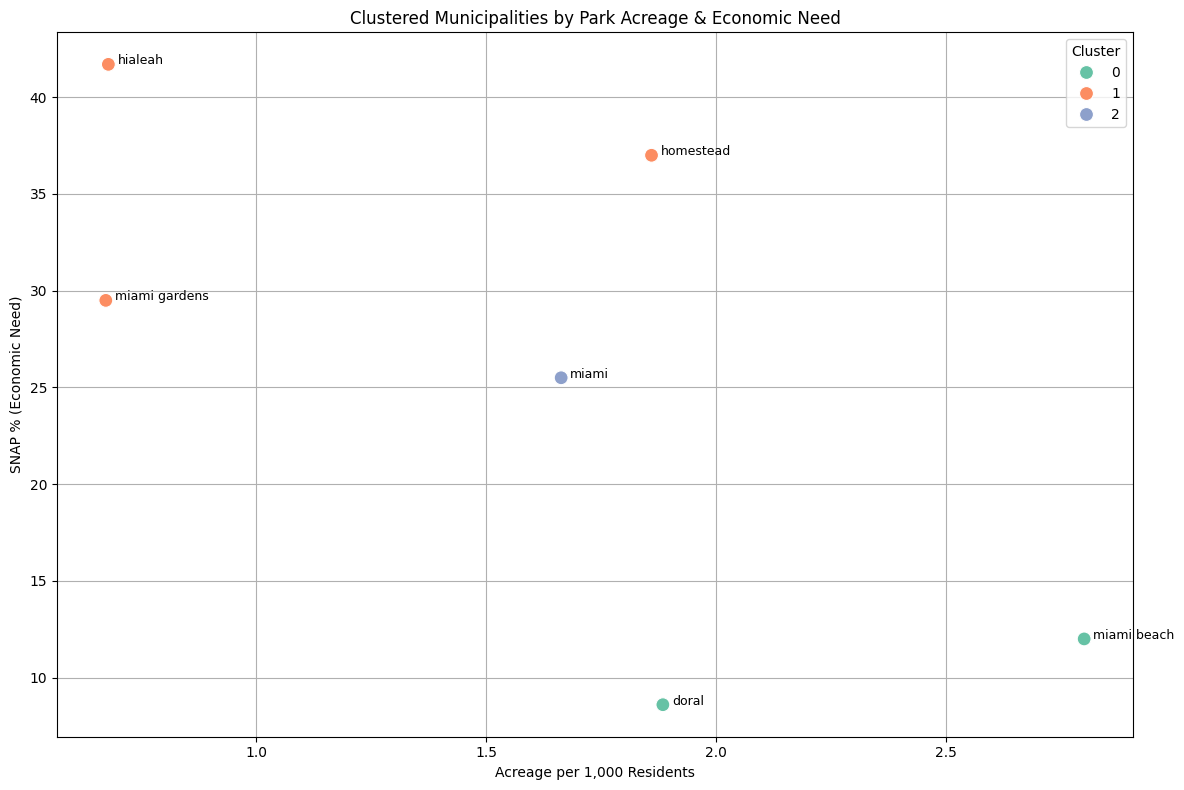

In [47]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=clustering_df,
                x='Acreage_Per_1000',
                y='SNAP_Percent',
                hue='Cluster',
                palette='Set2',
                s=100)


for i in range(clustering_df.shape[0]):
    plt.text(x=clustering_df['Acreage_Per_1000'].iloc[i] + 0.02,
             y=clustering_df['SNAP_Percent'].iloc[i],
             s=clustering_df['Municipality'].iloc[i],
             fontsize=9)

plt.title('Clustered Municipalities by Park Acreage & Economic Need')
plt.xlabel('Acreage per 1,000 Residents')
plt.ylabel('SNAP % (Economic Need)')
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()
plt.show()

Using K-Means clustering, we grouped municipalities based on park access, acreage, population size, and economic need. The resulting clusters enable us to visually identify areas that have both high need and low park access. This is especially useful for prioritizing policy interventions. For example, one cluster may represent municipalities with high SNAP rates and low acreage, suggesting they are underserved and could benefit the most from new green space investment.

##Hierarchical Clustering

In [49]:
linked = linkage(X_scaled, method='ward')

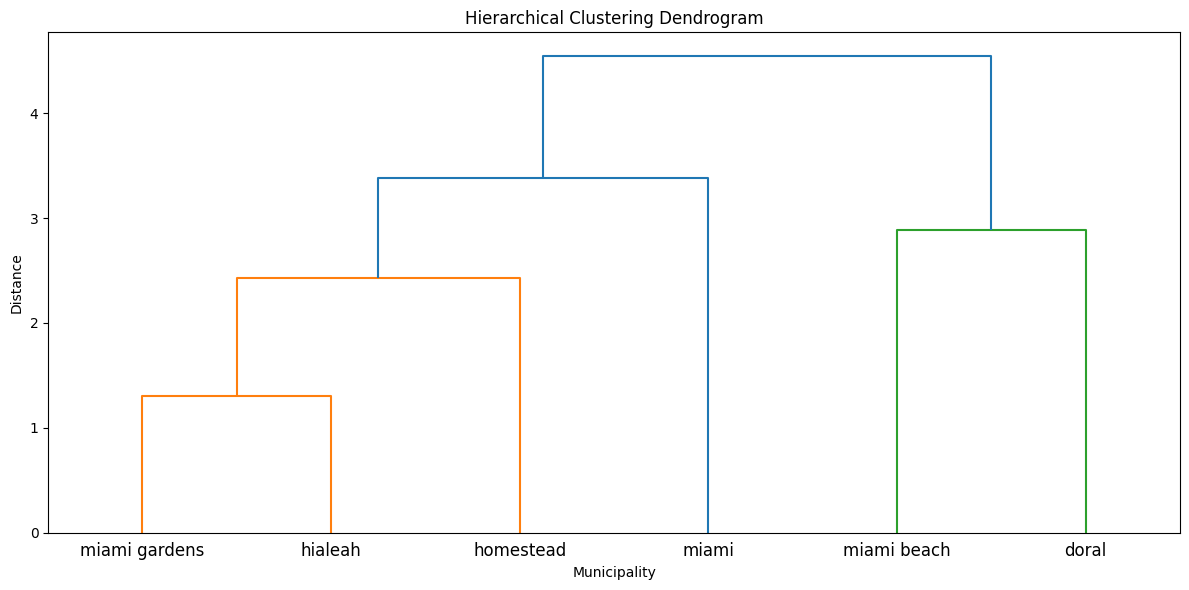

In [50]:
plt.figure(figsize=(12, 6))
dendrogram(linked,
           labels=clustering_df['Municipality'].values,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Municipality')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

The dendrogram groups municipalities based on their similarities in terms of park access, population, and economic need. Municipalities that are closely linked, such as Miami Gardens, Hialeah, and Homestead, share similar characteristics and form clusters earlier. On the other hand, places like Miami Beach and Doral appear more distinct and are grouped later, suggesting they differ more from the others in terms of the selected features.

This hierarchical view helps highlight how some cities may share similar challenges or advantages and can guide decision-makers when creating regional plans or equity-focused policies.

## Creative Visual: Interactive Map of Park Access

In [57]:
geolocator = Nominatim(user_agent="my_geocoder")

In [58]:
def get_coordinates(municipality):
    try:
        location = geolocator.geocode(f"{municipality}, Miami-Dade County, FL")
        if location:
            return location.latitude, location.longitude
        else:
            return None, None
    except Exception as e:
        print(f"Error geocoding {municipality}: {e}")
        return None, None


In [59]:
merged_df[['LAT', 'LON']] = merged_df['Municipality'].apply(lambda x: pd.Series(get_coordinates(x)))

Error geocoding homestead: HTTPSConnectionPool(host='nominatim.openstreetmap.org', port=443): Max retries exceeded with url: /search?q=homestead%2C+Miami-Dade+County%2C+FL&format=json&limit=1 (Caused by ReadTimeoutError("HTTPSConnectionPool(host='nominatim.openstreetmap.org', port=443): Read timed out. (read timeout=1)"))


In [60]:
miami_map = folium.Map(location=[25.7617, -80.1918], zoom_start=10)
marker_cluster = MarkerCluster().add_to(miami_map)

In [61]:
geo_df = merged_df.dropna(subset=['LAT', 'LON', 'Acreage_Per_1000', 'SNAP_Percent'])

In [62]:
for _, row in geo_df.iterrows():
    popup_text = f"""
    <b>Municipality:</b> {row['Municipality']}<br>
    <b>SNAP %:</b> {row['SNAP_Percent']}<br>
    <b>Acreage per 1,000:</b> {row['Acreage_Per_1000']}
    """
    folium.Circle(
        location=(row['LAT'], row['LON']),
        radius=row['Acreage_Per_1000'] * 100,  # scale up radius
        color='crimson' if row['SNAP_Percent'] > 20 else 'blue',
        fill=True,
        fill_opacity=0.6,
        popup=folium.Popup(popup_text, max_width=300)
    ).add_to(marker_cluster)

In [64]:
miami_map

**Interpretation: Interactive Map of Park Access**

This interactive map shows park access across Miami-Dade municipalities. The size of each circle represents park acreage per 1,000 residents, and the color highlights economic need:

🔴 Red = higher SNAP % (more need)
🔵 Blue = lower SNAP % (less need)

By combining these indicators, it is easy to identify municipalities where park space is limited despite high economic need — a key insight for targeting equity-focused urban improvements.

##Creative Visual: Bubble Chart (Need vs Access)

In [67]:
bubble_df = merged_df[['Municipality', 'Parks_Per_Capita', 'SNAP_Percent', 'Population_2023']].dropna()

In [68]:
fig = px.scatter(
    bubble_df,
    x='Parks_Per_Capita',
    y='SNAP_Percent',
    size='Population_2023',
    color='Municipality',
    hover_name='Municipality',
    size_max=60,
    title='SNAP % vs Parks per Capita by Municipality (Bubble = Population)',
    labels={
        'Parks_Per_Capita': 'Parks per Capita',
        'SNAP_Percent': 'SNAP %',
        'Population_2023': 'Population (2023)'
    }
)

In [69]:
fig.show()

**Interpretation: Bubble Chart – SNAP % vs Parks per Capita**

This bubble chart compares SNAP% % (y-axis) and parks per capita (x-axis) for each municipality. The bubble size reflects population, making it easy to see which larger communities may be underserved.

Municipalities in the top-left quadrant (high SNAP% %, low park access) are likely the most in need of additional public green spaces. This visual helps prioritize which areas could benefit most from investment.

To download the results:

In [29]:
merged_df.to_csv('park_equity_analysis_results.csv', index=False)
from google.colab import files
files.download('park_equity_analysis_results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>